# Project 2 — E-Commerce: Orders, Returns, and Profitability

**Business context:** An e-commerce marketplace operates across multiple regions and devices. Customers place orders, buy items, and sometimes return them. This notebook answers the COO's key questions about revenue, customer behavior, products, and returns.


In [1]:
# --- Setup: load the database ---
# This looks for sqllite.db in common locations first, so you only upload once per session.
# If the file is already visible in the Colab Files sidebar, this cell will find it automatically
# and will NOT ask you to upload it again.

import os

CUSTOM_DB_PATH = "sqllite.db"

candidate_paths = [
    CUSTOM_DB_PATH,
    "/content/sqllite.db",
    "/content/drive/MyDrive/sqllite.db",
]

DB_PATH = next((p for p in candidate_paths if p and os.path.exists(p)), None)

# Only prompts for upload if the file was not found anywhere above
if DB_PATH is None:
    from google.colab import files
    uploaded = files.upload()   # select sqllite.db
    DB_PATH = "sqllite.db"

# Option: mount Google Drive instead of uploading (persists across sessions):
# from google.colab import drive
# drive.mount("/content/drive")
# DB_PATH = "/content/drive/MyDrive/<folder_name>/sqllite.db"


In [2]:
import sqlite3
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

conn = sqlite3.connect(DB_PATH)

def run_query(query: str) -> pd.DataFrame:
    return pd.read_sql_query(query, conn)

def list_tables(connection=conn) -> pd.DataFrame:
    return pd.read_sql_query(
        "SELECT name AS table_name FROM sqlite_master WHERE type='table' ORDER BY name;",
        connection
    )

def show_schema(table_name: str, connection=conn) -> pd.DataFrame:
    safe_name = table_name.replace("'", "''")
    return pd.read_sql_query(f"PRAGMA table_info('{safe_name}');", connection)

print(f"Connected to: {DB_PATH}")


Connected to: sqllite.db


In [3]:
# Quick check that the connection works and the relevant tables are present
list_tables()


,table_name
0,p1_applications
1,p1_bureau_summary
2,p1_funded_loans
3,p1_payroll_monthly
4,p2_order_items
5,p2_orders
6,p2_returns
7,p2_users
8,p3_billing_monthly
9,p3_qos_daily


## Schema Reference — Project 2 tables

- **p2_users**: `user_id`, `region`, `channel`, `signup_dt`
- **p2_orders**: `order_id`, `user_id`, `order_dt`, `region`, `device` (Web/App), `gmv`, `discount`, `shipping_cost`, `cogs`
- **p2_order_items**: `order_id`, `sku` (CATEGORY-######), `qty`, `price`
- **p2_returns**: `order_id`, `return_dt`, `reason`

Categories (from the `sku` prefix): ELEC, HOME, FASH, SPORT, BEAUTY, GROC


---

## Explore the Tables — Rows & Columns

### p2_users

In [4]:
show_schema("p2_users")


,cid,name,type,notnull,dflt_value,pk
0,0,user_id,INTEGER,0,None,0
1,1,signup_dt,TIMESTAMP,0,None,0
2,2,channel,TEXT,0,None,0
3,3,region,TEXT,0,None,0


In [5]:
query = """
SELECT COUNT(*) AS row_count FROM p2_users;
"""
result = run_query(query)
result


,row_count
0,3000


In [6]:
query = """
SELECT * FROM p2_users LIMIT 5;
"""
result = run_query(query)
result


,user_id,signup_dt,channel,region
0,200001,2025-03-25 06:28:44,Direct,AbuDhabi
1,200002,2024-01-04 10:27:44,Social,Giza
2,200003,2024-06-02 19:27:41,Social,Alexandria
3,200004,2025-02-25 09:56:22,SEO,Alexandria
4,200005,2024-10-23 05:50:14,Social,Giza


### p2_orders

In [7]:
show_schema("p2_orders")


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,INTEGER,0,None,0
1,1,user_id,INTEGER,0,None,0
2,2,order_dt,TIMESTAMP,0,None,0
3,3,gmv,REAL,0,None,0
4,4,discount,REAL,0,None,0
5,5,cogs,REAL,0,None,0
6,6,shipping_cost,REAL,0,None,0
7,7,region,TEXT,0,None,0
8,8,device,TEXT,0,None,0


In [8]:
query = """
SELECT COUNT(*) AS row_count FROM p2_orders;
"""
result = run_query(query)
result


,row_count
0,15000


In [9]:
query = """
SELECT * FROM p2_orders LIMIT 5;
"""
result = run_query(query)
result


,order_id,user_id,order_dt,gmv,discount,cogs,shipping_cost,region,device
0,600001,200831,2024-07-19 19:36:34,941.20,0.00,627.02,3.20,Alexandria,App
1,600002,200475,2025-04-13 18:41:37,585.89,64.52,388.47,4.90,AbuDhabi,Web
2,600003,200161,2024-07-07 19:50:50,322.75,48.16,247.46,3.91,Alexandria,App
3,600004,200979,2024-02-23 16:12:42,481.61,65.53,335.42,2.62,Cairo,App
4,600005,202677,2025-05-26 06:44:07,92.03,13.99,57.80,2.38,Cairo,Web


### p2_order_items

In [10]:
show_schema("p2_order_items")


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,INTEGER,0,None,0
1,1,sku,TEXT,0,None,0
2,2,qty,INTEGER,0,None,0
3,3,price,REAL,0,None,0


In [11]:
query = """
SELECT COUNT(*) AS row_count FROM p2_order_items;
"""
result = run_query(query)
result


,row_count
0,38655


In [12]:
query = """
SELECT * FROM p2_order_items LIMIT 5;
"""
result = run_query(query)
result


,order_id,sku,qty,price
0,600001,FASH-000001,2,74.75
1,600001,BEAUTY-000002,2,75.22
2,600001,SPORT-000003,1,99.39
3,600001,GROC-000004,1,19.57
4,600001,ELEC-000005,2,215.54


### p2_returns

In [13]:
show_schema("p2_returns")


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,INTEGER,0,None,0
1,1,return_dt,TIMESTAMP,0,None,0
2,2,reason,TEXT,0,None,0


In [14]:
query = """
SELECT COUNT(*) AS row_count FROM p2_returns;
"""
result = run_query(query)
result


,row_count
0,1531


In [15]:
query = """
SELECT * FROM p2_returns LIMIT 5;
"""
result = run_query(query)
result


,order_id,return_dt,reason
0,600001,2024-08-04 19:36:34,Changed mind
1,600006,2024-11-19 04:48:01,Damaged
2,600007,2025-12-22 15:42:29,Wrong size
3,600036,2024-11-21 06:10:23,Changed mind
4,600040,2025-11-06 08:14:20,Late delivery


---

## 1. Revenue & Margins

### How much revenue did we make month by month, before and after discounts?

In [16]:
query = """
SELECT strftime('%Y-%m', order_dt) AS month,
       ROUND(SUM(gmv), 2)            AS revenue_before_discount,
       ROUND(SUM(gmv - discount), 2) AS revenue_after_discount
FROM p2_orders
GROUP BY month
ORDER BY month;
"""
result = run_query(query)
result
##hady 1

,month,revenue_before_discount,revenue_after_discount
0,2024-01,5554.10,4823.75
1,2024-02,26320.20,23420.48
2,2024-03,43155.76,38235.14
3,2024-04,56663.77,51171.86
4,2024-05,82498.43,73980.05
5,2024-06,93500.59,83852.98
6,2024-07,97414.16,87764.72
7,2024-08,123082.04,110234.85
8,2024-09,152758.62,136888.29
9,2024-10,162121.97,145901.68


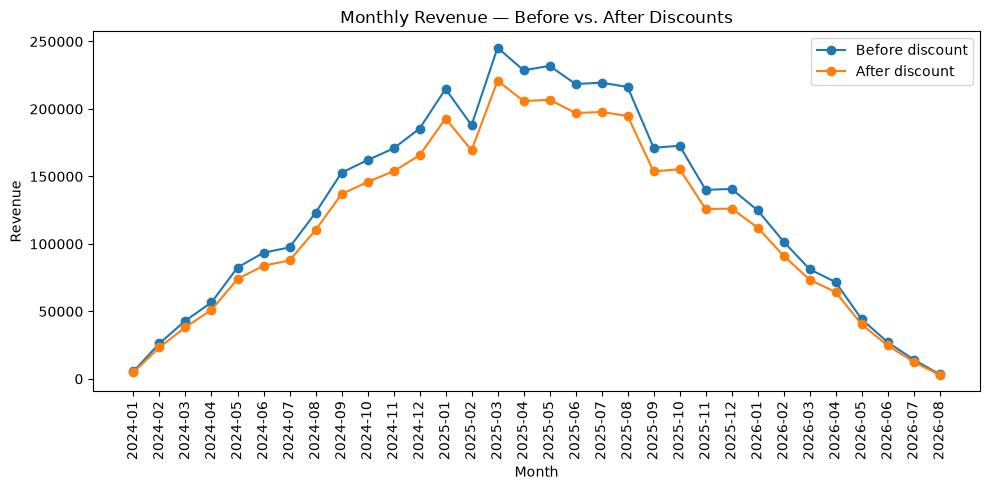

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result["month"], result["revenue_before_discount"], marker="o", label="Before discount")
ax.plot(result["month"], result["revenue_after_discount"], marker="o", label="After discount")

ax.set_title("Monthly Revenue — Before vs. After Discounts")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Takeaway: revenue grows steadily through early 2025, then declines —
# worth investigating whether this is driven by fewer new customers or lower order value.

### Which regions give us the best margins after costs?

In [18]:
query = """
SELECT region,
       COUNT(*) AS total_orders,
       ROUND(SUM(gmv - discount - cogs - shipping_cost), 2) AS total_margin,
       ROUND(AVG(gmv - discount - cogs - shipping_cost), 2) AS avg_margin_per_order,
       ROUND(100.0 * SUM(gmv - discount - cogs - shipping_cost) / SUM(gmv), 2) AS margin_pct_of_gmv
FROM p2_orders
GROUP BY region
ORDER BY margin_pct_of_gmv DESC;
"""
result = run_query(query)
result
##hady 2

,region,total_orders,total_margin,avg_margin_per_order,margin_pct_of_gmv
0,Alexandria,2146,125831.22,58.64,21.50
1,Cairo,4129,236264.26,57.22,21.28
2,Giza,2620,146282.91,55.83,21.20
3,Jeddah,2461,136350.03,55.40,21.05
4,Riyadh,2627,154350.99,58.76,20.93
5,AbuDhabi,1017,58139.01,57.17,20.40


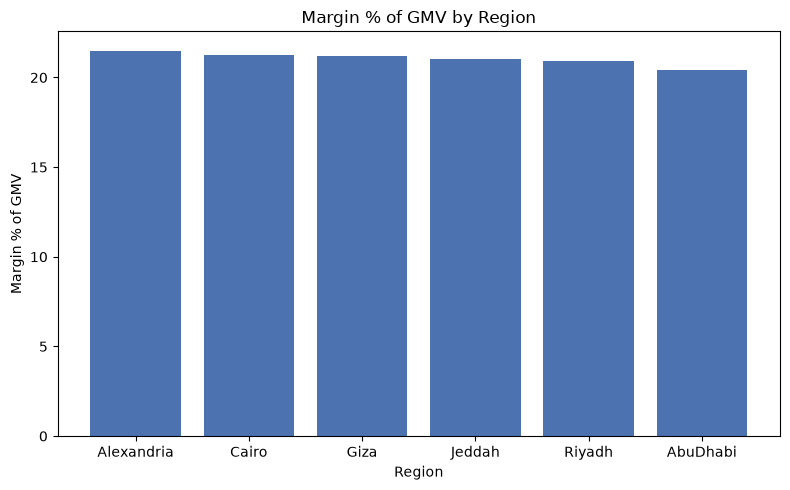

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result["region"], result["margin_pct_of_gmv"], color="#4C72B0")
ax.set_title("Margin % of GMV by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Margin % of GMV")
plt.tight_layout()
plt.show()

# Takeaway: margin % is fairly close across regions (~20-21.5%) —
# Alexandria edges out slightly, AbuDhabi is the lowest.


### Which product categories are more expensive on average?

In [20]:
query = """
SELECT SUBSTR(sku, 1, INSTR(sku, '-') - 1) AS category,
       ROUND(AVG(price), 2) AS avg_price,
       COUNT(*) AS items_sold
FROM p2_order_items
GROUP BY category
ORDER BY avg_price DESC;
"""
result = run_query(query)
result
##hady 3

,category,avg_price,items_sold
0,ELEC,164.57,6449
1,SPORT,80.04,6426
2,HOME,64.71,6556
3,FASH,47.72,6395
4,BEAUTY,42.25,6326
5,GROC,21.02,6503


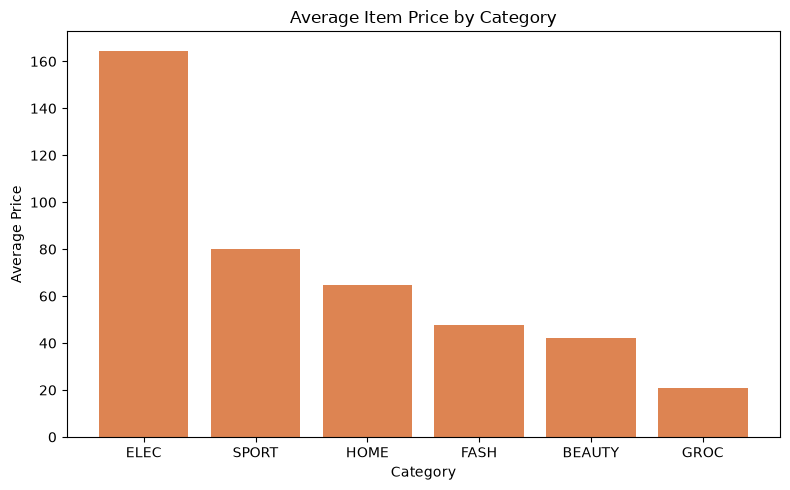

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result["category"], result["avg_price"], color="#DD8452")
ax.set_title("Average Item Price by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average Price")
plt.tight_layout()
plt.show()

# Takeaway: ELEC is by far the most expensive category on average (~165),
# roughly double SPORT, the next highest.


---

## 2. Customer Lifecycle

How quickly do new customers make their first purchase?

In [22]:
query = """
SELECT
    ROUND(AVG(days_to_order), 1) AS avg_days_to_first_purchase,
    MIN(days_to_order) AS min_days,
    MAX(days_to_order) AS max_days
FROM (
    SELECT
        JULIANDAY(first_order.first_order_dt) - JULIANDAY(p2_users.signup_dt) AS days_to_order
    FROM p2_users
    JOIN (
        SELECT user_id, MIN(order_dt) AS first_order_dt
        FROM p2_orders
        GROUP BY user_id
    ) AS first_order
    ON p2_users.user_id = first_order.user_id
);
"""
result = run_query(query)
result
##yousef 1

,avg_days_to_first_purchase,min_days,max_days
0,75.3,1.0,394.0


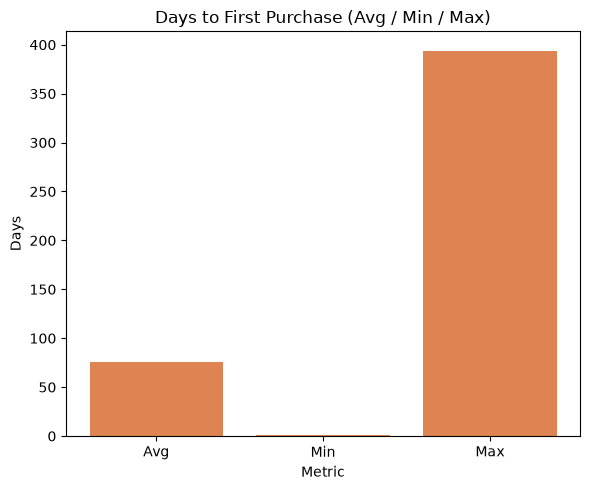

In [23]:
import matplotlib.pyplot as plt

labels = ["Avg", "Min", "Max"]
values = [result["avg_days_to_first_purchase"][0], result["min_days"][0], result["max_days"][0]]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(labels, values, color="#DD8452")
ax.set_title("Days to First Purchase (Avg / Min / Max)")
ax.set_xlabel("Metric")
ax.set_ylabel("Days")
plt.tight_layout()
plt.show()

### What % of customers come back after their first order?

In [24]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(100.0 * SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_pct
FROM (
    SELECT user_id, COUNT(*) AS num_orders
    FROM p2_orders
    GROUP BY user_id
);
"""
result = run_query(query)
result
##yousef 2

,total_customers,repeat_customers,repeat_pct
0,2973,2873,96.64


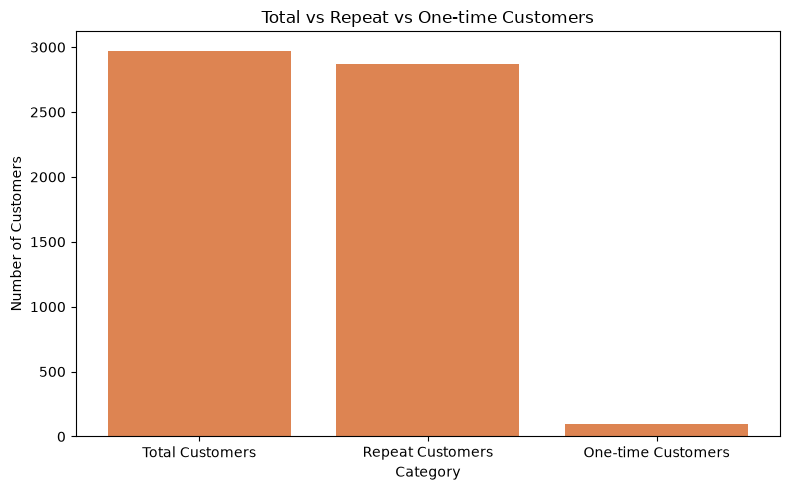

In [25]:
import matplotlib.pyplot as plt

total = result["total_customers"][0]
repeat = result["repeat_customers"][0]
one_time = total - repeat

labels = ["Total Customers", "Repeat Customers", "One-time Customers"]
values = [total, repeat, one_time]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, values, color="#DD8452")
ax.set_title("Total vs Repeat vs One-time Customers")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### How long do customers wait between their first and second order?

In [26]:
query = """
SELECT
    ROUND(AVG(JULIANDAY(second_order_dt) - JULIANDAY(first_order_dt)), 1) AS avg_days_between_orders
FROM (
    SELECT
        user_id,
        MAX(CASE WHEN rn = 1 THEN order_dt END) AS first_order_dt,
        MAX(CASE WHEN rn = 2 THEN order_dt END) AS second_order_dt
    FROM (
        SELECT
            user_id, order_dt,
            ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY order_dt) AS rn
        FROM p2_orders
    )
    WHERE rn <= 2
    GROUP BY user_id
)
WHERE second_order_dt IS NOT NULL;
"""
result = run_query(query)
result
##yousef 3

,avg_days_between_orders
0,72.8


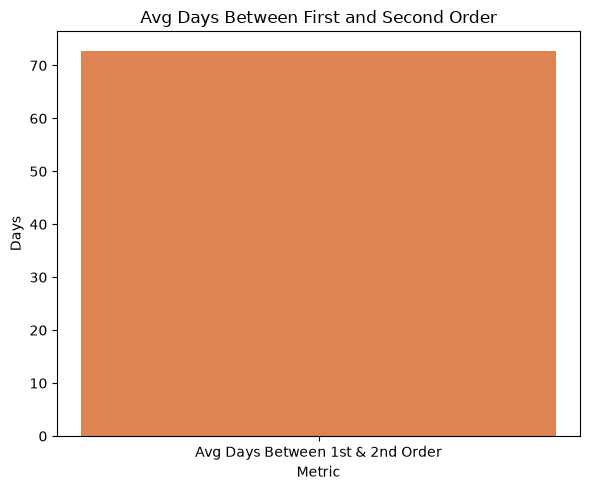

In [27]:
import matplotlib.pyplot as plt

value = result["avg_days_between_orders"][0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Avg Days Between 1st & 2nd Order"], [value], color="#DD8452")
ax.set_title("Avg Days Between First and Second Order")
ax.set_xlabel("Metric")
ax.set_ylabel("Days")
plt.tight_layout()
plt.show()

---

## 3. Customer Value

### Who are the top 10 customers by spend, and how many orders did they make?

In [28]:
query = """
SELECT
    user_id,
    COUNT(order_id) AS orders_count,
    ROUND(SUM(gmv - discount), 2) AS total_paid
FROM p2_orders
GROUP BY user_id
ORDER BY total_paid DESC
LIMIT 10;
"""
result = run_query(query)
result
##toma 1

,user_id,orders_count,total_paid
0,202164,13,6564.20
1,202283,11,5060.43
2,200630,9,4341.48
3,202958,11,4089.75
4,201209,10,4004.65
5,202859,11,3969.99
6,201105,12,3924.80
7,202091,8,3889.37
8,200324,11,3855.37
9,200496,7,3851.94


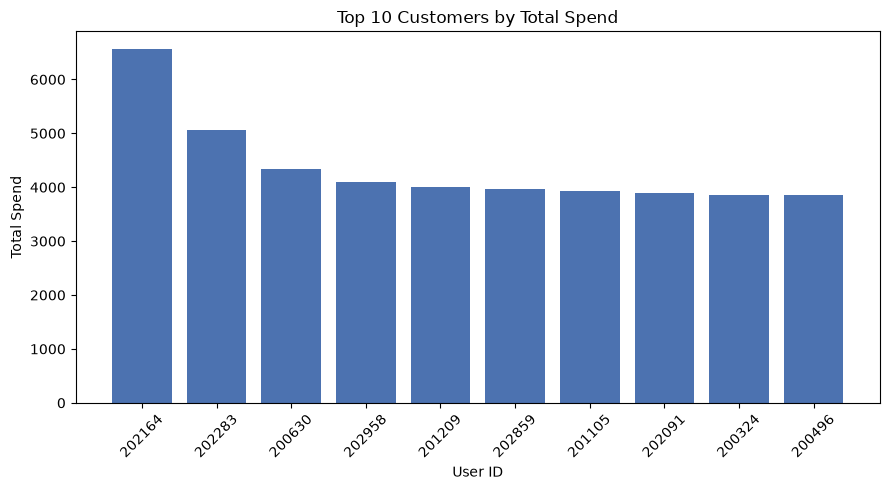

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(result["user_id"].astype(str), result["total_paid"], color="#4C72B0")
ax.set_title("Top 10 Customers by Total Spend")
ax.set_xlabel("User ID")
ax.set_ylabel("Total Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Takeaway: the top customer (202164) spends roughly 30% more than the next
# highest — everyone else in the top 10 is fairly close together (~4,200-5,500).

### Each month, how many orders come from new vs. returning customers?

In [30]:
query = """
SELECT
    strftime('%Y-%m', o.order_dt) AS order_month,
    SUM(CASE WHEN o.order_dt = f.first_date THEN 1 ELSE 0 END) AS new_orders,
    SUM(CASE WHEN o.order_dt != f.first_date THEN 1 ELSE 0 END) AS repeat_orders
FROM p2_orders o
JOIN (
    SELECT user_id, MIN(order_dt) AS first_date
    FROM p2_orders
    GROUP BY user_id
) f ON o.user_id = f.user_id
GROUP BY order_month
ORDER BY order_month;
"""
result = run_query(query)
result
##toma 2

,order_month,new_orders,repeat_orders
0,2024-01,24,3
1,2024-02,74,19
2,2024-03,104,71
3,2024-04,114,90
4,2024-05,142,155
5,2024-06,135,198
6,2024-07,142,253
7,2024-08,162,311
8,2024-09,166,371
9,2024-10,176,418


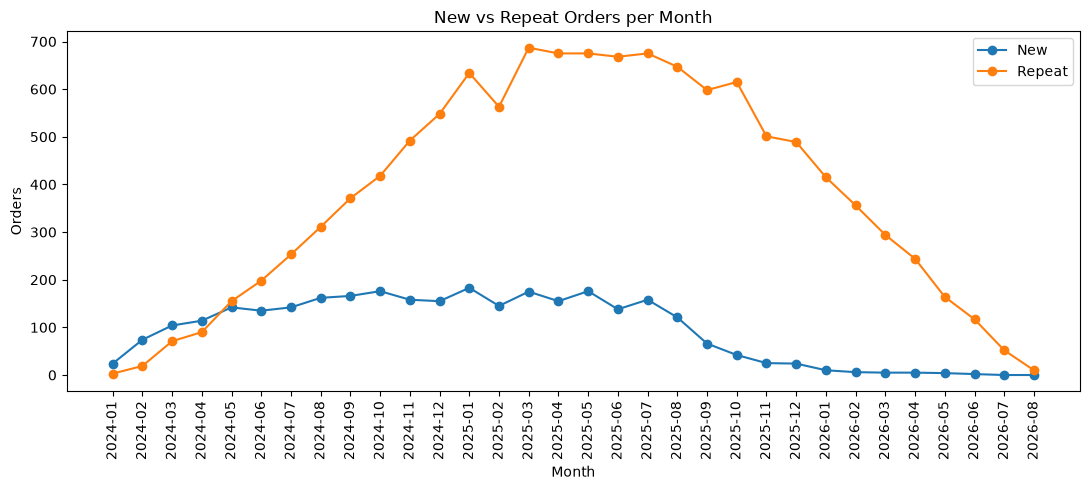

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(result["order_month"], result["new_orders"], marker="o", label="New")
ax.plot(result["order_month"], result["repeat_orders"], marker="o", label="Repeat")
ax.set_title("New vs Repeat Orders per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Takeaway: repeat orders overtake new orders by around mid-2024 and keep growing
# while new orders shrink after early 2025 — the business is increasingly running
# on existing customers rather than new acquisition.

### How recent are most customers' last purchases (are many inactive)?

In [32]:
query = """
WITH LastPurchase AS (
    SELECT user_id, MAX(order_dt) AS last_date
    FROM p2_orders
    GROUP BY user_id
)
SELECT
    strftime('%Y-%m', last_date) AS last_seen_month,
    COUNT(user_id) AS users_count
FROM LastPurchase
GROUP BY last_seen_month
ORDER BY last_seen_month DESC;
"""
result = run_query(query)
result
##toma 3

,last_seen_month,users_count
0,2026-08,10
1,2026-07,41
2,2026-06,79
3,2026-05,99
4,2026-04,142
5,2026-03,125
6,2026-02,160
7,2026-01,147
8,2025-12,164
9,2025-11,155


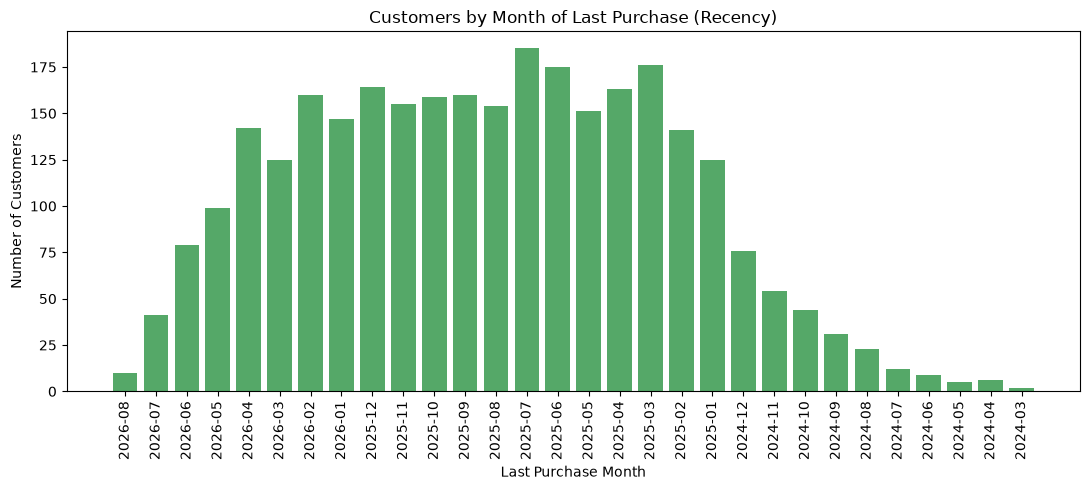

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(result["last_seen_month"], result["users_count"], color="#55A868")
ax.set_title("Customers by Month of Last Purchase (Recency)")
ax.set_xlabel("Last Purchase Month")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Takeaway: most customers' last purchase falls in the more recent months, which is
# expected since the dataset itself ends in 2026-08 — the real question is what %
# haven't ordered in the last 60-90 days counting from that end date, which would need
# a small follow-up query (days since last order vs. the max order date in the data).

---

## 4. Products, Device & Returns

### Which product categories drive the most sales?

In [34]:
"""
Ibrahim
"""
query = """
select substr(sku, 1, instr(sku, '-') - 1) as category,
sum(price * qty) as total_sales
from p2_order_items
group by category
order by total_sales desc
"""
result = run_query(query)
result
##ibrahem 1


,category,total_sales
0,ELEC,1594473.44
1,SPORT,769572.45
2,HOME,632194.52
3,FASH,452325.34
4,BEAUTY,402970.71
5,GROC,203994.32


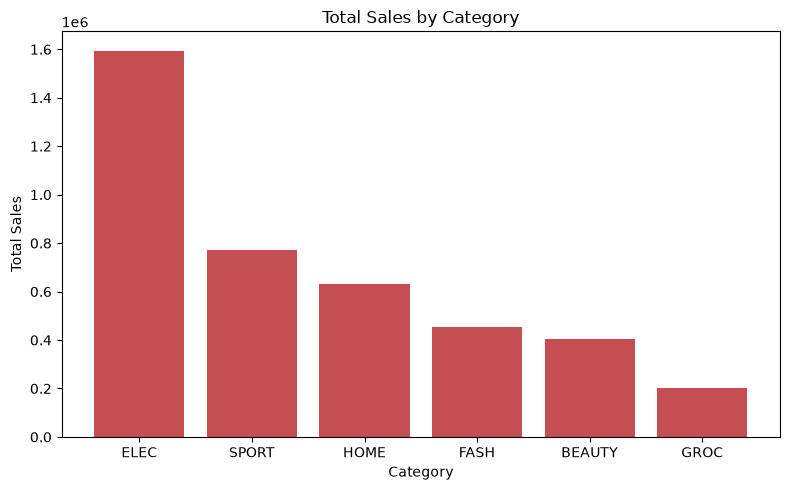

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result["category"], result["total_sales"], color="#C44E52")
ax.set_title("Total Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()

# Takeaway: ELEC drives the most total sales by far (~1.6M), more than double
# the next category (SPORT) — consistent with it also having the highest average price.

### Do more orders come from mobile or desktop?

In [36]:
"""
Ibrahim
"""
query = """
select device, count(order_id) as total_orders from p2_orders
group by device
order by total_orders desc
"""
result = run_query(query)
result
##ibrahem 2

,device,total_orders
0,Web,8086
1,App,6914


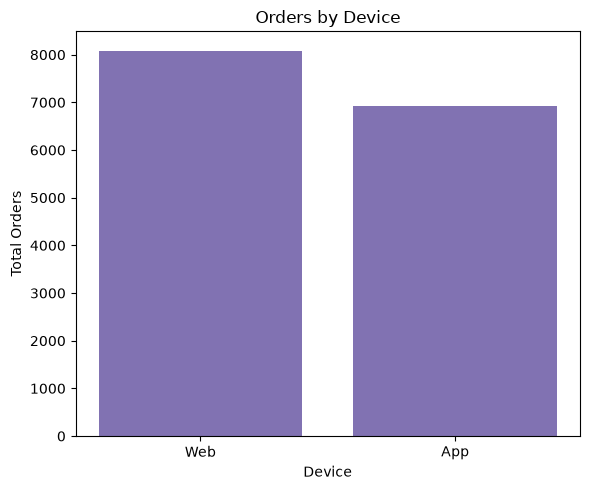

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(result["device"], result["total_orders"], color="#8172B2")
ax.set_title("Orders by Device")
ax.set_xlabel("Device")
ax.set_ylabel("Total Orders")
plt.tight_layout()
plt.show()

# Takeaway: Web brings in more orders than App (8,086 vs 6,914) — roughly a 54/46 split.

### On average, how many items are in each order?

In [38]:
"""
Ibrahim
"""
query = """
select avg(total_items) as average_items_per_order from
(
  select order_id, sum(qty) as total_items from p2_order_items
  group by order_id
) as item_per_order
"""
result = run_query(query)
result

##ibrahem 3

,average_items_per_order
0,3.860533


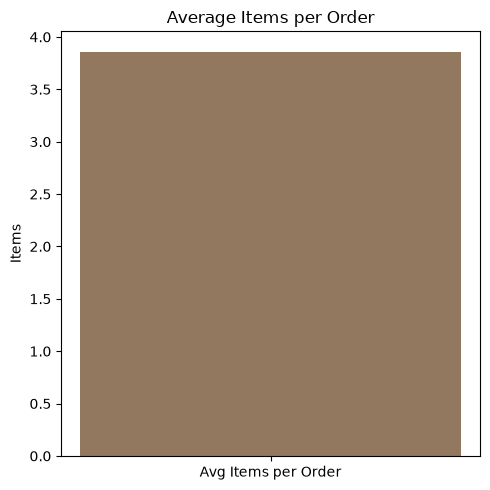

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Avg Items per Order"], [result["average_items_per_order"][0]], color="#937860")
ax.set_title("Average Items per Order")
ax.set_ylabel("Items")
plt.tight_layout()
plt.show()

# Takeaway: customers put about 3.9 items in their cart on average per order.


### Do mobile app users spend more per order than web users?

---



In [40]:
query = """
SELECT device,
       ROUND(AVG(gmv - discount), 2) AS avg_order_value
FROM p2_orders
GROUP BY device;
"""
result = run_query(query)
result
##sha3bn 1

,device,avg_order_value
0,App,243.21
1,Web,242.69


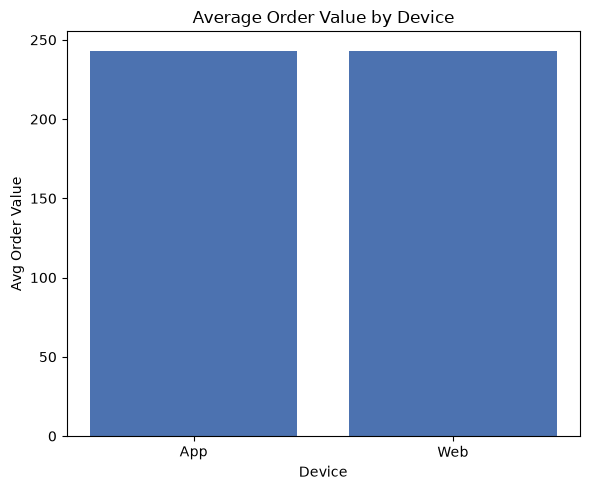

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(result["device"], result["avg_order_value"], color="#4C72B0")
ax.set_title("Average Order Value by Device")
ax.set_xlabel("Device")
ax.set_ylabel("Avg Order Value")
plt.tight_layout()
plt.show()

# Takeaway: App and Web users spend almost the same per order (~243 vs ~243) —
# device barely affects order value once someone has decided to buy.



  ### Do some regions have higher return rates than others?

In [42]:
query = """
SELECT o.region,
       COUNT(DISTINCT r.order_id) AS returned_orders,
       COUNT(DISTINCT o.order_id) AS total_orders,
       ROUND(COUNT(DISTINCT r.order_id) * 100.0 / COUNT(DISTINCT o.order_id), 2) AS return_rate_pct
FROM p2_orders o
LEFT JOIN p2_returns r ON o.order_id = r.order_id
GROUP BY o.region
ORDER BY return_rate_pct DESC;

"""
result = run_query(query)
result
##sha3bn 2

,region,returned_orders,total_orders,return_rate_pct
0,Cairo,442,4129,10.70
1,Jeddah,260,2461,10.56
2,AbuDhabi,102,1017,10.03
3,Riyadh,263,2627,10.01
4,Alexandria,214,2146,9.97
5,Giza,250,2620,9.54


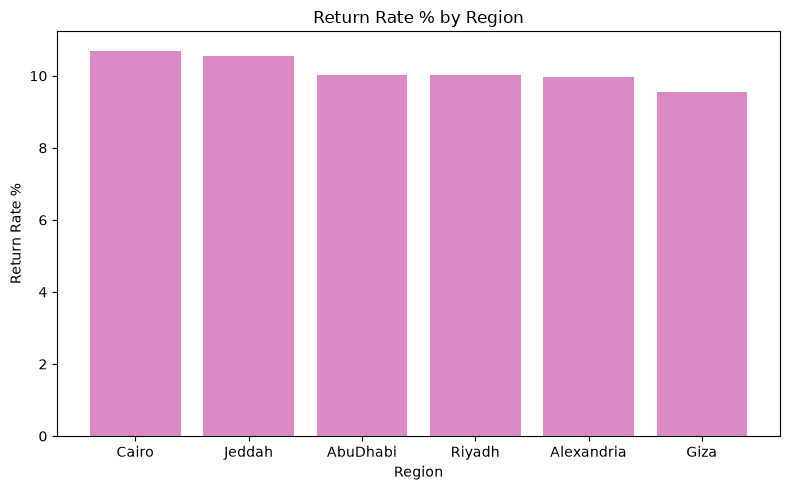

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result["region"], result["return_rate_pct"], color="#DA8BC3")
ax.set_title("Return Rate % by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Return Rate %")
plt.tight_layout()
plt.show()

# Takeaway: return rates are close across regions (~9.5%-10.7%), with Cairo
# slightly the highest and Giza the lowest — not a dramatic gap.

### What are the top reasons for returns?

In [44]:
query = """
SELECT reason, COUNT(*) AS cnt
FROM p2_returns
GROUP BY reason
ORDER BY cnt DESC;

"""
result = run_query(query)
result
##sha3bn 3

,reason,cnt
0,Damaged,441
1,Wrong size,394
2,Changed mind,304
3,Late delivery,233
4,Other,159


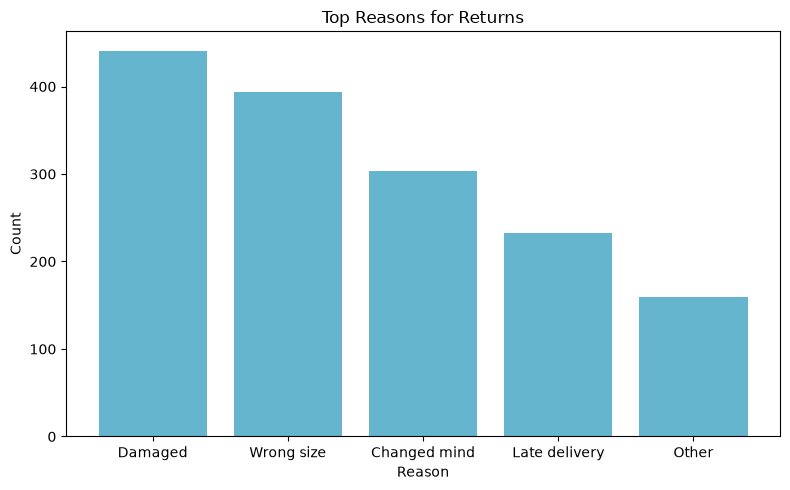

In [45]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result["reason"], result["cnt"], color="#64B5CD")
ax.set_title("Top Reasons for Returns")
ax.set_xlabel("Reason")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Takeaway: "Damaged" and "Wrong size" together make up more than half of all
# returns — worth investigating packaging/QA (damaged) and sizing guides (wrong size).

---

## 5. Visualizations & Dashboard Prep

In [46]:
# Space to combine the key results above into charts before moving them into the final dashboard (Power BI / Tableau / Looker Studio)
import matplotlib.pyplot as plt

# result.plot(kind="bar", x="...", y="...")
# plt.show()
